# Проект: Модель предсказания покупательского спроса

Интернет-магазин «В один клик» предлагает широкий ассортимент товаров: детские товары, товары для дома, мелкую бытовую технику, косметику и продукты питания. Несмотря на высокую узнаваемость бренда и широкую охват целевой аудитории, отчёт за последний период показал снижение покупательской активности.

Привлечение новых клиентов стало менее эффективным, поэтому основной акцент смещается на удержание и реактивацию существующих пользователей.

**Цель исследования:**  
Разработать решение, основанное на анализе данных, которое позволит:  
    1. Персонализировать предложения для клиентов.  
    2. Повысить покупательскую активность.  
    3. Улучшить показатели удержания клиентов.  

**Задачи исследования:**  
Провести исследование данных, понять как признаки влияют друг на друга, обучить модель и сегментировать клиентов, после чего сделать выводы.

**Исходны данные:**  
Четыре датасета, предоставленные компанией "В один клик".
1. market_file.csv — поведенческие и маркетинговые данные
Поле	Описание  
id	Уникальный идентификатор покупателя  
Покупательская активность	Целевой признак: «снизилась» или «прежний уровень»  
Тип сервиса	Уровень обслуживания: «премиум», «стандарт»  
Разрешить сообщать	Согласие на получение маркетинговых предложений (Да/Нет)  
Маркет_актив_6_мес	Среднемесячное число маркетинговых воздействий за 6 месяцев  
Маркет_актив_тек_мес	Количество маркетинговых воздействий за текущий месяц  
Длительность	Количество дней с момента регистрации  
Акционные_покупки	Среднемесячная доля покупок по акциям за 6 месяцев  
Популярная_категория	Чаще всего покупаемая товарная категория за 6 месяцев  
Средний_просмотр_категорий_за_визит	Среднее число категорий, просмотренных за визит  
Неоплаченные_продукты_штук_квартал	Общее число неоплаченных товаров в корзине за квартал  
Ошибка_сервиса	Количество зафиксированных сбоев для покупателя  
Страниц_за_визит	Среднее количество просмотренных страниц за визит за 3 месяца  

2. market_money.csv — выручка по клиентам  
Поле	Описание  
id	Уникальный идентификатор покупателя  
Период	Период сбора данных: «текущий_месяц», «предыдущий_месяц»  
Выручка	Сумма выручки, полученной от клиента за указанный период  

3. market_time.csv — время, проведённое на сайте  
Поле	Описание  
id	Уникальный идентификатор покупателя  
Период	Период сбора данных (как в market_money.csv)  
минут	Время, проведённое на сайте в указанный период (в минутах)  

4. money.csv — прибыльность клиентов  
Поле	Описание  
id	Уникальный идентификатор покупателя  
Прибыль	Среднемесячная прибыль за 3 последних месяца  


**Данное исследование разделим на несколько частей:**    

***Часть 1: Изучение общих свединий о данных.***  
*1. Загрузим данные, загрузим библиотеки.*  
*2. Проверим данные на пропуски.*  

***Часть 2: Подготовка данных.***  
*1. Проверим данные на явные и не явные дубликаты.*  
*2. При необходимости отчистим данные.*  
***Часть 3: Исследование данных.***  
*1. Проведём исследовательский анализ данных.*  
*2. Построим графики для признаков.*  
*3. Сделаем выводы по полученным данным.*  
***Часть 4: Определим корреляцию между признаками.***  
*1. Объеденим датасеты.*  
*2. Построим матрицу корреляций.*  
***Часть 5: Построение модели.***  
*1. Создадим пайплайны для работы с моделью.*  
*2. Обучим несколько моделей.*  
*3. Выберем наиболее подходящую для нас модель.*  
***Часть 6: Анализ важности признаков.***  
*1. Проведём анализ важности признаков.*  
*2. Сделаем вывод о значимости признаков.*  
***Часть 7: Вывод.***  
*1. Подведём итог исследования.*  

## Загрузка данных

Импортируем библиотеки и загрузим данные.

### Импортируем библиотеки

In [1]:
!pip install phik -q
!pip install scikit-learn -U -q
!pip install shap -q

In [2]:
import pandas as pd
import numpy as np
import sklearn
import shap
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import seaborn as sns
from phik import phik_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder, 
    MinMaxScaler)
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score, 
    roc_auc_score,
    make_scorer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [3]:
RANDOM_STATE = 42

Библиотеки импортированы.

### Загрузка датасетов

In [4]:
try:
    market_file = pd.read_csv('C:/Users/Professional/Downloads/market_file.csv')
    market_money = pd.read_csv('C:/Users/Professional/Downloads/market_money.csv')
    market_time = pd.read_csv('C:/Users/Professional/Downloads/market_time.csv')
    money = pd.read_csv('C:/Users/Professional/Downloads/money.csv', sep=';', decimal=',')
    print("Файлы успешно загружены из локальной директории.")
except FileNotFoundError:
    try:
        # Альтернативный путь — /datasets
        market_file = pd.read_csv('/datasets/market_file.csv')
        market_money = pd.read_csv('/datasets/market_money.csv')
        market_time = pd.read_csv('/datasets/market_time.csv')
        money = pd.read_csv('/datasets/money.csv', sep=';', decimal=',')
        print("Файлы успешно загружены из /datasets.")
    except Exception as e:
        print("Не удалось загрузить файлы ни из локального пути, ни из /datasets.")
        print("Ошибка:", e)

Файлы успешно загружены из /datasets.


In [5]:
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [6]:
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [7]:
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [8]:
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


In [9]:
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [10]:
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


In [11]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [12]:
money.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Библиотеки импортированы, дата сеты загружены, типы данных корректные.

## Предобработка данных

Пропусков в данных нет.

### Проверка данных на дубликаты

In [13]:
print(f'В таблице market_file явных дубликатов: ', market_file.duplicated().sum())
print(f'В таблице market_money явных дубликатов: ', market_money.duplicated().sum())
print(f'В таблице market_time явных дубликатов: ', market_time.duplicated().sum())
print(f'В таблице money явных дубликатов: ', money.duplicated().sum())

В таблице market_file явных дубликатов:  0
В таблице market_money явных дубликатов:  0
В таблице market_time явных дубликатов:  0
В таблице money явных дубликатов:  0


Явных дубликатов в таблицах нет.

### Проверка на неявные дубликаты

In [14]:
for col in market_file.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(market_file[col].unique())
    print("-" * 40)

Уникальные значения в столбце 'Покупательская активность':
['Снизилась' 'Прежний уровень']
----------------------------------------
Уникальные значения в столбце 'Тип сервиса':
['премиум' 'стандартт' 'стандарт']
----------------------------------------
Уникальные значения в столбце 'Разрешить сообщать':
['да' 'нет']
----------------------------------------
Уникальные значения в столбце 'Популярная_категория':
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']
----------------------------------------


In [15]:
for col in market_money.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(market_money[col].unique())
    print("-" * 40)

Уникальные значения в столбце 'Период':
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']
----------------------------------------


In [16]:
for col in market_time.select_dtypes(include='object').columns:
    print(f"Уникальные значения в столбце '{col}':")
    print(market_time[col].unique())
    print("-" * 40)

Уникальные значения в столбце 'Период':
['текущий_месяц' 'предыдцщий_месяц']
----------------------------------------


Увидели неявные дубликаты в столбцах market_file['Тип сервиса'],  также заметна опечатка в столбце market_time['Период'] - поправим данные проблемы.

In [17]:
market_file['Тип сервиса'] = market_file['Тип сервиса'].replace({'стандартт': 'стандарт'})
print(market_file['Тип сервиса'].unique())

['премиум' 'стандарт']


In [18]:
market_file['Популярная_категория'] = market_file['Популярная_категория'].replace({'Косметика и аксесуары': 'Косметика и аксессуары'})
print(market_file['Популярная_категория'].unique())

['Товары для детей' 'Домашний текстиль' 'Косметика и аксессуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


In [19]:
market_time['Период'] = market_time['Период'].replace({'предыдцщий_месяц': 'предыдущий_месяц'})
print(market_time['Период'].unique())

['текущий_месяц' 'предыдущий_месяц']


Обработали неявные дубликаты и ошибки написания.

## Исследовательский анализ данных

Проведём исследовательский анализ данных, исследуем данные в каждой таблице.

Создадим несколько функций, которые позволят упростить однотипные дейтсвия.

In [20]:
def plot_boxplot(df, column, title = None, figsize=(6,4)):
    plt.figure(figsize=figsize)
    df.boxplot(column=column)
    plt.title(title)
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

In [21]:
def plot_distr(df, column, bins = 30, kde = True, figsize = (8,5), title = None):
    plt.figure(figsize=figsize)
    sns.histplot(df[column], bins=bins, kde = kde, color='skyblue', edgecolor='black')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()

In [22]:
def plot_value_counts(df, column, figsize=(8,5), title = None):
    value_counts=df[column].value_counts()
    plt.figure(figsize=figsize)
    value_counts.plot(kind='bar', color='cornflowerblue', edgecolor='black')
    plt.title(title or f'Частота значений {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.grid(axis='y')
    plt.show()

### Исследуем датасет market_file

Начнём исследование с датасета market_file

In [23]:
market_file.shape

(1300, 13)

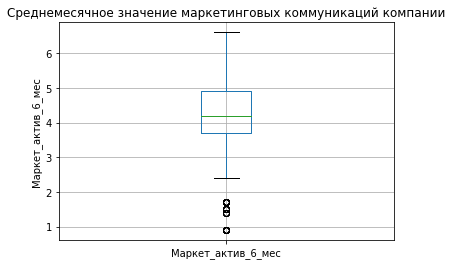

In [24]:
plot_boxplot(market_file, 'Маркет_актив_6_мес', title ='Среднемесячное значение маркетинговых коммуникаций компании')

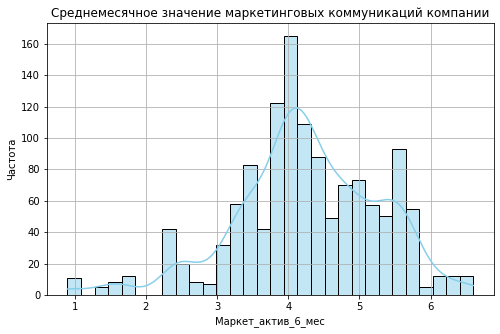

In [25]:
plot_distr(market_file, 'Маркет_актив_6_мес', title ='Среднемесячное значение маркетинговых коммуникаций компании')

Видны несколько выбросов, распределение похоже на бимодальное.

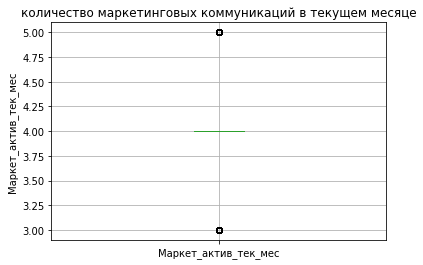

In [26]:
plot_boxplot(market_file, 'Маркет_актив_тек_мес', title ='количество маркетинговых коммуникаций в текущем месяце')

In [27]:
market_file['Маркет_актив_тек_мес'].max()

5

In [28]:
market_file['Маркет_актив_тек_мес'].min()

3

In [29]:
market_file['Маркет_актив_тек_мес'].median()

4.0

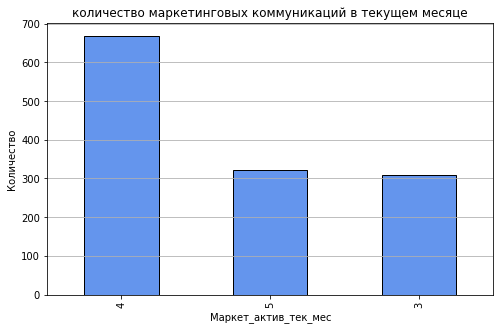

In [30]:
plot_value_counts(market_file, 'Маркет_актив_тек_мес', title ='количество маркетинговых коммуникаций в текущем месяце')

Количество коммуникаций всегда или 3 или 4 или 5, при этом коммуникаций с количеством 4 явно больше остальных.

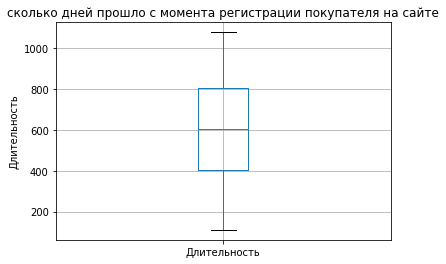

In [31]:
plot_boxplot(market_file, 'Длительность', title ='сколько дней прошло с момента регистрации покупателя на сайте')

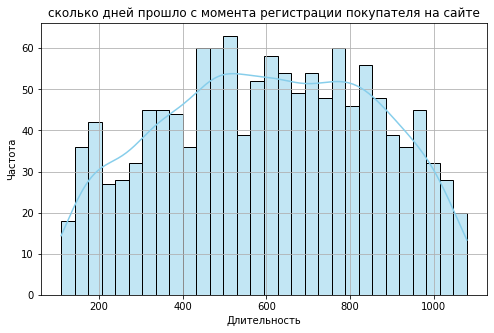

In [32]:
plot_distr(market_file, 'Длительность', title ='сколько дней прошло с момента регистрации покупателя на сайте')

In [33]:
stat, p = shapiro(market_file['Длительность'])
print(f'p-value:, {p:.20f}')

p-value:, 0.00000000000000579148


Тест Шапиро показал результат менее 0,05, следовательно это не нормальное распределение.

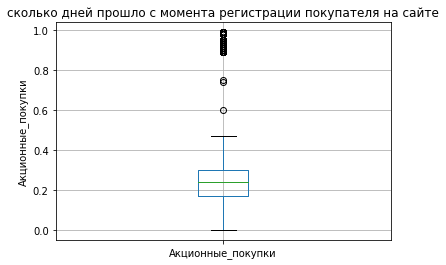

In [34]:
plot_boxplot(market_file, 'Акционные_покупки', title ='сколько дней прошло с момента регистрации покупателя на сайте')

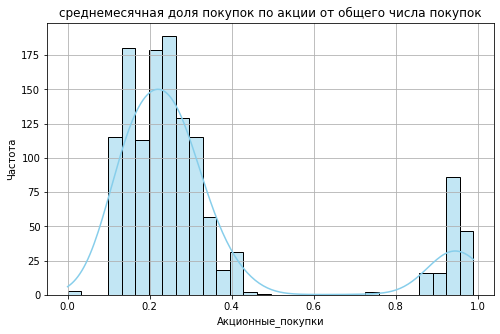

In [35]:
plot_distr(market_file, 'Акционные_покупки', title ='среднемесячная доля покупок по акции от общего числа покупок')

Видно бимодальное распределение, часть людей покупали только товары по акции.

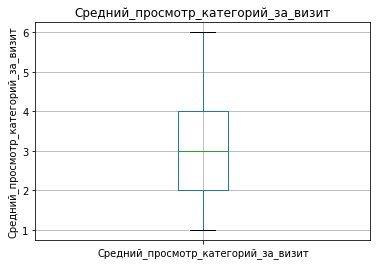

In [36]:
plot_boxplot(market_file, 'Средний_просмотр_категорий_за_визит', title ='Средний_просмотр_категорий_за_визит')

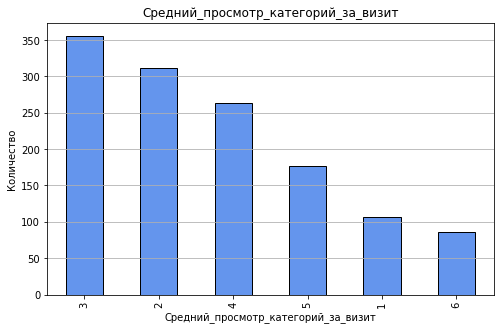

In [37]:
plot_value_counts(market_file, 'Средний_просмотр_категорий_за_визит', title ='Средний_просмотр_категорий_за_визит')

Количество категорий от 1 до 6, самая часть встречаемая это категория 3.

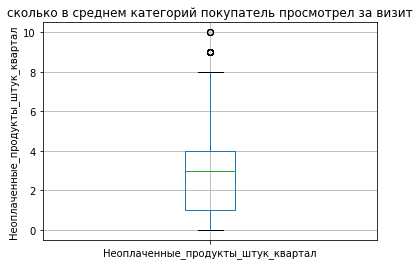

In [38]:
plot_boxplot(market_file, 'Неоплаченные_продукты_штук_квартал', title ='сколько в среднем категорий покупатель просмотрел за визит')

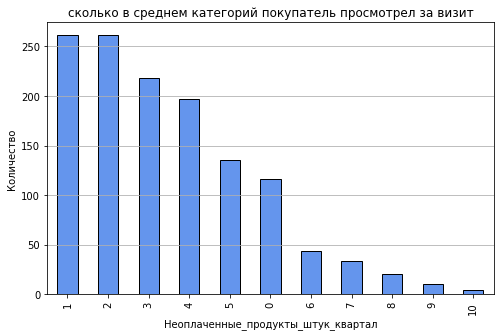

In [39]:
plot_value_counts(market_file, 'Неоплаченные_продукты_штук_квартал', title ='сколько в среднем категорий покупатель просмотрел за визит')

Наиболее часто клиенты оставляют в корзине один или два товара.

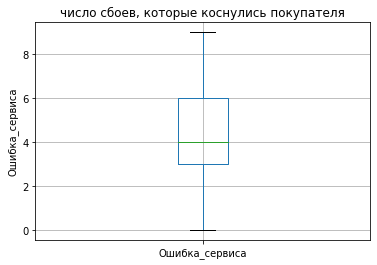

In [40]:
plot_boxplot(market_file, 'Ошибка_сервиса', title ='число сбоев, которые коснулись покупателя')

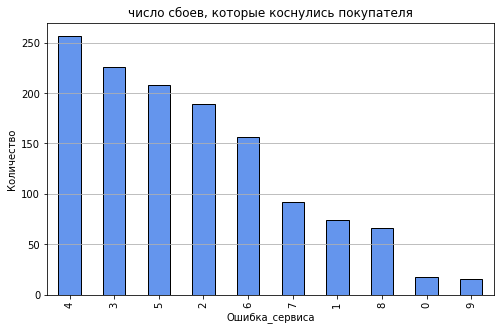

In [41]:
plot_value_counts(market_file, 'Ошибка_сервиса', title ='число сбоев, которые коснулись покупателя')

Большая часть клиентов столкнулись встретили от 2 до 6 технических проблем.

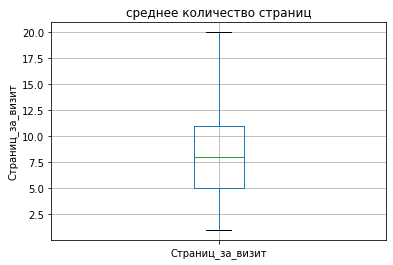

In [42]:
plot_boxplot(market_file, 'Страниц_за_визит', title ='среднее количество страниц')

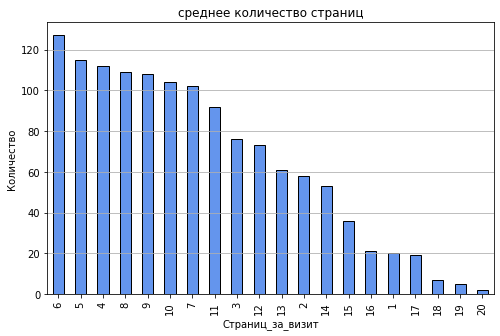

In [43]:
plot_value_counts(market_file, 'Страниц_за_визит', title ='среднее количество страниц')

Чаще всего клиенты просмтаривают 6 страниц.

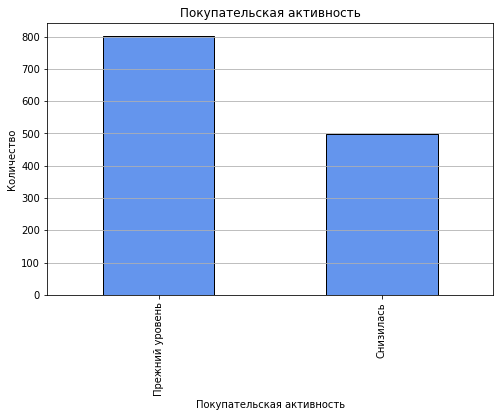

In [44]:
plot_value_counts(market_file, 'Покупательская активность', title ='Покупательская активность')

800 покупателей остались на прежнем уровне покупательской активности, около 500 снизило свою активность. Нужно будет учесть это при обучении модели и использовать стратификацию.

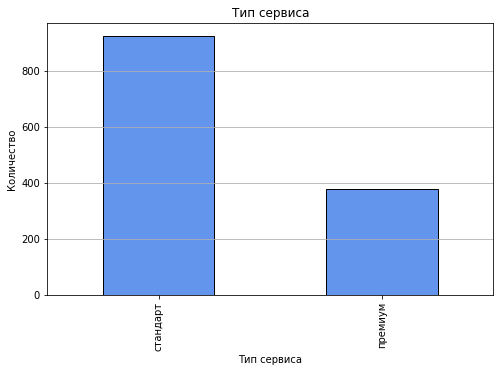

In [45]:
plot_value_counts(market_file, 'Тип сервиса', title ='Тип сервиса')

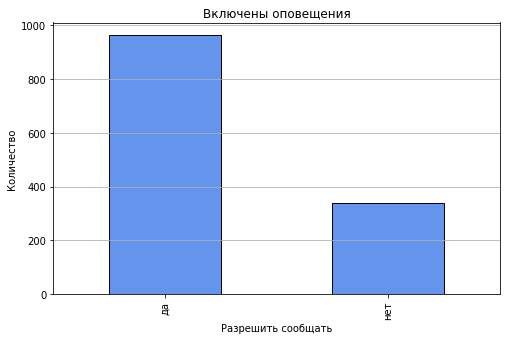

In [46]:
plot_value_counts(market_file, 'Разрешить сообщать', title ='Включены оповещения')

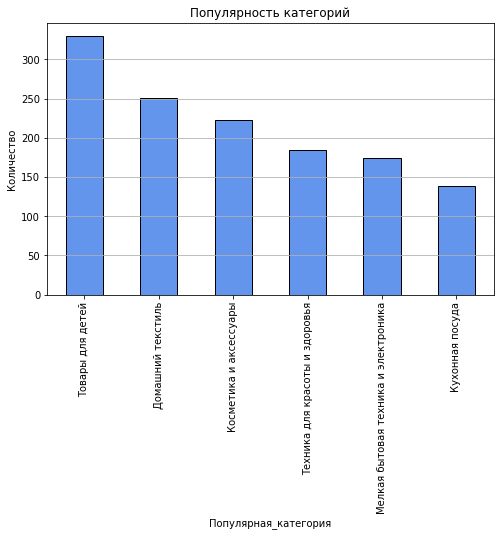

In [47]:
plot_value_counts(market_file, 'Популярная_категория', title ='Популярность категорий')

Самой большой популярностью пользуются товары для детей.

### Исследуем датасет market_money

In [48]:
market_money.shape

(3900, 3)

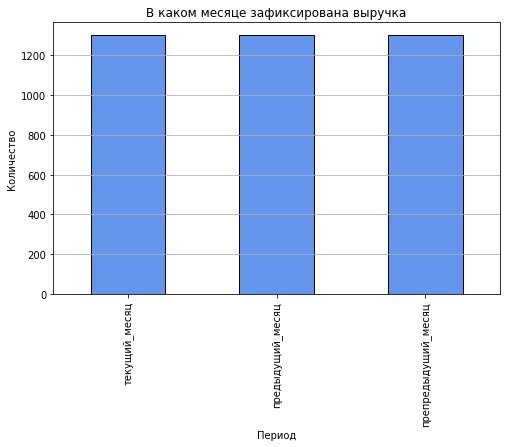

In [49]:
plot_value_counts(market_money, 'Период', title ='В каком месяце зафиксирована выручка')

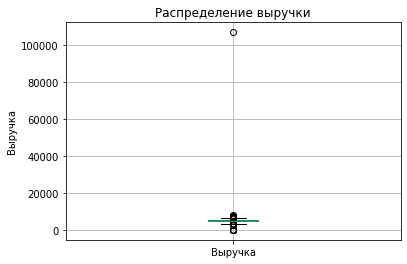

In [50]:
plot_boxplot(market_money, 'Выручка', title ='Распределение выручки')

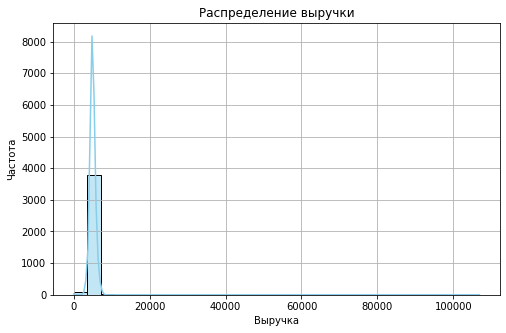

In [51]:
plot_distr(market_money, 'Выручка', title ='Распределение выручки')

In [52]:
market_money['Выручка'].median()

4957.5

Медианное значение выручки 4957.5, так же мы видим явный выброс, проверим его и решим что делать дальше.

In [53]:
market_money.loc[market_money['Выручка'] == market_money['Выручка'].max()]

,id,Период,Выручка
98,215380,текущий_месяц,106862.2


Думаю, следует убрать это значение, так как оно слишком сильно искажает средние значения. 

In [54]:
market_money = market_money[market_money['Выручка'] != 106862.2]


Так же по заданию уберем клиентов, у которых нулевая покупательская активность за последние 3 месяца.

In [55]:
market_money.shape

(3899, 3)

In [56]:
pivoted = market_money.pivot_table(
    index='id',
    columns='Период',
    values='Выручка',
    aggfunc='sum'  
)

filtered = pivoted[(pivoted != 0).all(axis=1)]

filtered_ids = filtered.index
market_money= market_money[market_money['id'].isin(filtered_ids)]

In [57]:
market_money.shape

(3890, 3)

Убрали тех клиентов, у которых не было покупок в любом из трёх месяцев.

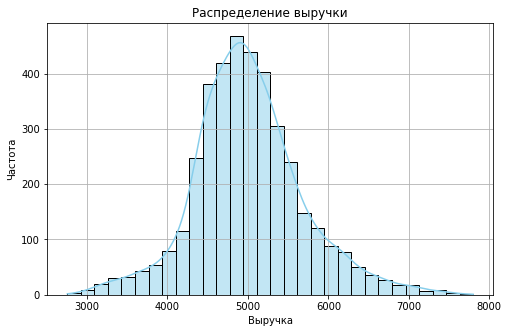

In [58]:
plot_distr(market_money, 'Выручка', title ='Распределение выручки')

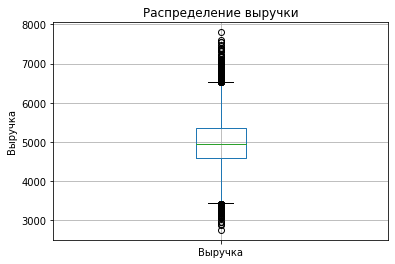

In [59]:
plot_boxplot(market_money, 'Выручка', title ='Распределение выручки')

In [60]:
market_money.shape

(3890, 3)

In [61]:
stat, p = shapiro(market_money['Выручка'])
print(f'p-value:, {p:.40f}')

p-value:, 0.0000000000000000000005100447456764449076


Убрали аномальный выброс, также убрали неактивных клиентов. Размер датамета сократился на 7 строк, видимо большое количество выбросов, по резултатам теста Шапиро, видно что распределение не нормальное.

### Исследуем датасет market_time

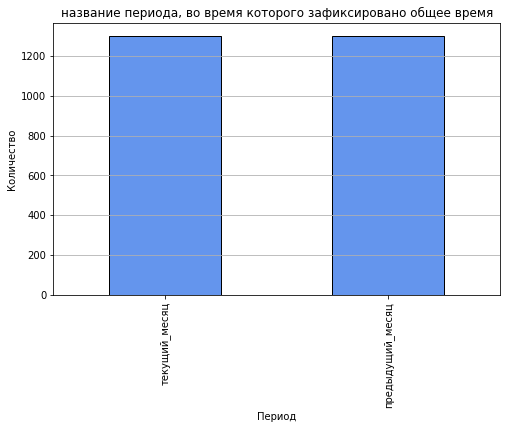

In [62]:
plot_value_counts(market_time, 'Период', title ='название периода, во время которого зафиксировано общее время')

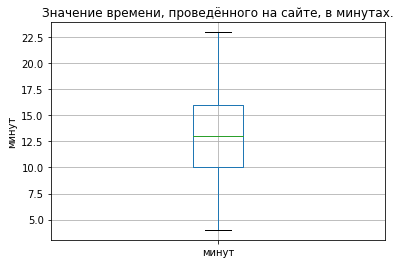

In [63]:
plot_boxplot(market_time, 'минут', title ='Значение времени, проведённого на сайте, в минутах.')

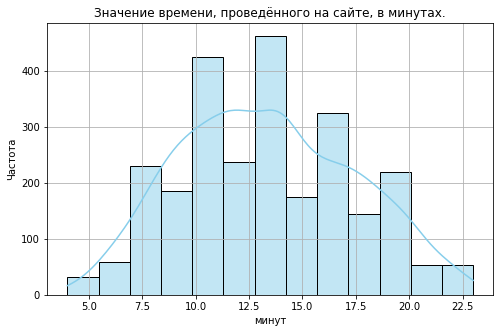

In [64]:
plot_distr(market_time, 'минут', bins = 13,  title ='Значение времени, проведённого на сайте, в минутах.')

### Исследуем датасет money

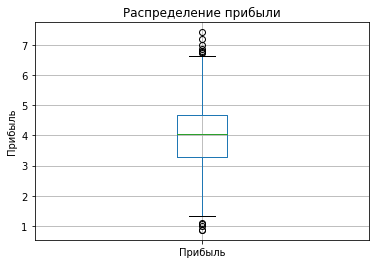

In [65]:
plot_boxplot(money, 'Прибыль', title = 'Распределение прибыли')

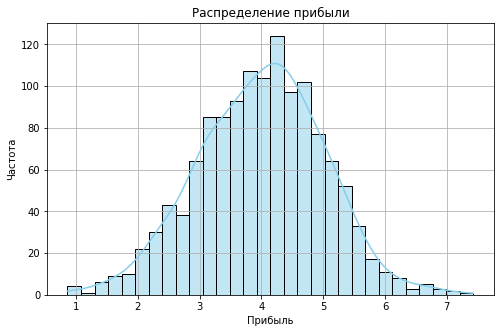

In [66]:
plot_distr(money, 'Прибыль', title = 'Распределение прибыли')

In [67]:
stat, p = shapiro(money['Прибыль'])
print(f'p-value:, {p:.40f}')

p-value:, 0.2580398917198181152343750000000000000000


Есть несколько выбросов, однако распределение номральное.

### Объединение таблиц

Объеденим таблицы, разобьем тыблицы по периодам.

In [68]:
market_time.shape

(2600, 3)

In [69]:
df_time_wide = market_time.pivot_table(
    index='id',     
    columns='Период',
    values='минут',
    aggfunc='first'
).reset_index()

In [70]:
df_time_wide.head()

Период,id,предыдущий_месяц,текущий_месяц
0,215348,13,14
1,215349,12,10
2,215350,8,13
3,215351,11,13
4,215352,8,11


In [71]:
df_time_wide = df_time_wide.rename(columns={'предыдущий_месяц': 'общее_время_за_прошлый_месяц',
                                           'текущий_месяц': 'общее_время_за_текущий_месяц'})

In [72]:
df_time_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   id                            1300 non-null   int64
 1   общее_время_за_прошлый_месяц  1300 non-null   int64
 2   общее_время_за_текущий_месяц  1300 non-null   int64
dtypes: int64(3)
memory usage: 30.6 KB


In [73]:
df_time_wide.shape

(1300, 3)

In [74]:
market_money.shape

(3890, 3)

In [75]:
df_money_wide = market_money.pivot_table(
    index='id',     
    columns='Период',
    values='Выручка',
    aggfunc='first'
).reset_index()

In [76]:
df_money_wide.shape

(1297, 4)

In [77]:
df_money_wide.head()

Период,id,предыдущий_месяц,препредыдущий_месяц,текущий_месяц
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5


In [78]:
df_money_wide = df_money_wide.rename(columns={'предыдущий_месяц': 'общая_выручка_за_предыдущий_месяц',
                                           'препредыдущий_месяц': 'общая_выручка_за_препредыдущий_месяц',
                                           'текущий_месяц': 'общая_выручка_за_текущий_месяц'})

In [79]:
df_money_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1297 entries, 0 to 1296
Data columns (total 4 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    1297 non-null   int64  
 1   общая_выручка_за_предыдущий_месяц     1297 non-null   float64
 2   общая_выручка_за_препредыдущий_месяц  1297 non-null   float64
 3   общая_выручка_за_текущий_месяц        1296 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 40.7 KB


Проверим , откуда появились пропуски

In [80]:
df_money_wide[df_money_wide.isna().any(axis=1)]

Период,id,общая_выручка_за_предыдущий_месяц,общая_выручка_за_препредыдущий_месяц,общая_выручка_за_текущий_месяц
29,215380,6077.0,5051.0,NaN


Скорее всего, проблема возникла, так как клиент еще не сделал ни одной покупки в этом месяце.  
По условию, мы должны убрать клиентов, с покупательской активностью менее трёх месяцев, однако мы не можем утверждать,  
что в этом месяце клиент ничего некупит, так как месяц еще не закончен.  
При этом и обратного мы утверждать не можем.  
Думаю исключить одну строчку будет самым надежным решением.

In [81]:
df_money_wide = df_money_wide.dropna()
df_money_wide.shape

(1296, 4)

объеденим три датасета в один

In [82]:
market_file.shape

(1300, 13)

In [83]:
df = market_file.merge(df_time_wide, on = 'id', how = 'left') \
                .merge(df_money_wide, on = 'id', how = 'inner')

In [84]:
df.shape

(1296, 18)

Количество строк изменилось, остались только те, которые пересекатются между таблицами, новые столбцы добавились.

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1296 entries, 0 to 1295
Data columns (total 18 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    1296 non-null   int64  
 1   Покупательская активность             1296 non-null   object 
 2   Тип сервиса                           1296 non-null   object 
 3   Разрешить сообщать                    1296 non-null   object 
 4   Маркет_актив_6_мес                    1296 non-null   float64
 5   Маркет_актив_тек_мес                  1296 non-null   int64  
 6   Длительность                          1296 non-null   int64  
 7   Акционные_покупки                     1296 non-null   float64
 8   Популярная_категория                  1296 non-null   object 
 9   Средний_просмотр_категорий_за_визит   1296 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал    1296 non-null   int64  
 11  Ошибка_сервиса   

## Корреляционый анализ

Проведем корреляционный анализ признаков.

Уберем значение id из списка столбцов.

In [86]:
df_without_id = df.drop(columns='id')

In [87]:
correlation_matrix = df_without_id.phik_matrix(interval_cols=[
    'Маркет_актив_6_мес',
    'Длительность',
    'Акционные_покупки',
    'общее_время_за_прошлый_месяц',
    'общее_время_за_текущий_месяц',
    'общая_выручка_за_предыдущий_месяц',
    'общая_выручка_за_препредыдущий_месяц',
    'общая_выручка_за_текущий_месяц'])

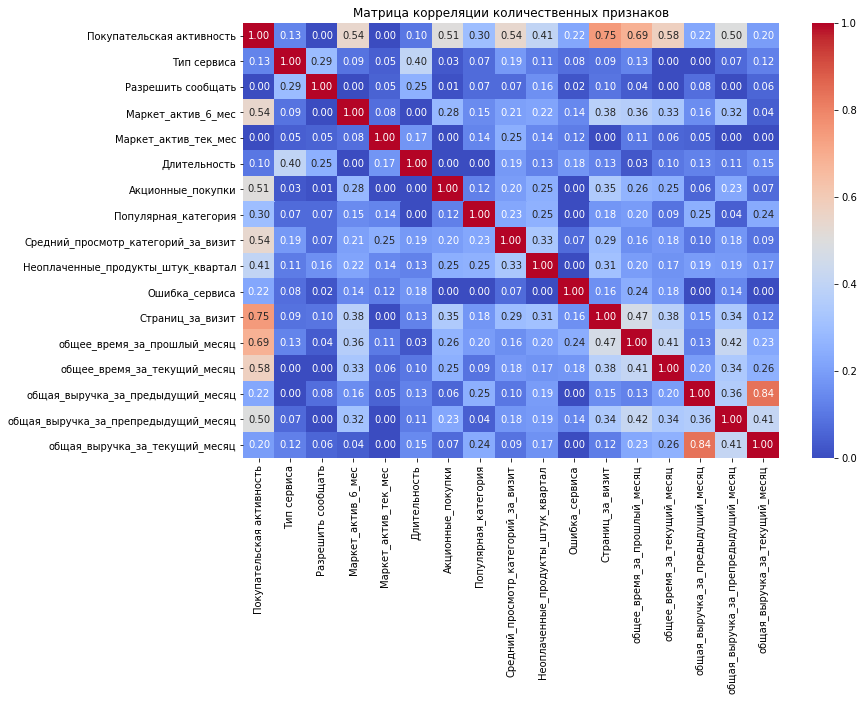

In [88]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции количественных признаков')
plt.show()

Мультиколлениарности не наблюдаю.

## Используем пайплайн

Создадим пайплайн и обучим четыре модели.

In [89]:
df = df.set_index('id')
X = df.drop('Покупательская активность', axis = 1)
y = df['Покупательская активность']

num_features_std = ['Средний_просмотр_категорий_за_визит', 'Страниц_за_визит']
num_features_minmax = ['Длительность', 'Маркет_актив_6_мес', 'Маркет_актив_тек_мес',
                       'Акционные_покупки', 'Неоплаченные_продукты_штук_квартал', 'Ошибка_сервиса','общее_время_за_прошлый_месяц',
                       'общее_время_за_текущий_месяц','общая_выручка_за_предыдущий_месяц','общая_выручка_за_препредыдущий_месяц',
                       'общая_выручка_за_текущий_месяц']

cat_features_ohe = ['Популярная_категория', 'Тип сервиса']
cat_features_ord = ['Разрешить сообщать']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y)



In [90]:
X_train.shape


(972, 16)

In [91]:
X_test.shape

(324, 16)

Используем стратификацию, так как количество значений целевого признака не одинаковые.

In [92]:
cat_pipe_ohe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


cat_pipe_ord = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])


num_pipe_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])


num_pipe_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

In [93]:
preprocessor = ColumnTransformer(transformers=[
    ('num_minmax', num_pipe_minmax, num_features_minmax),
    ('num_std', num_pipe_std, num_features_std),
    ('cat_ohe', cat_pipe_ohe, cat_features_ohe),
    ('cat_ord', cat_pipe_ord, cat_features_ord)
])

In [94]:
f1_scorer = make_scorer(f1_score, pos_label='Снизилась')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    'knn': (KNeighborsClassifier(), {'model__n_neighbors': [3, 5, 7]}),
    'tree': (DecisionTreeClassifier(random_state=RANDOM_STATE), {'model__max_depth': [3, 5, 10]}),
    'logreg': (LogisticRegression(max_iter=1000), {'model__C': [0.1, 1, 10]}),
    'svc': (SVC(), {'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf']})
}

best_score = 0
best_model = None
best_name = ''
best_params = {}

for name, (model, params) in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    grid = GridSearchCV(pipe,
                        param_grid=params,
                        cv=cv,
                        scoring=f1_scorer,
                        n_jobs=-1)
    grid.fit(X_train, y_train)
    
    print(f"Модель: {name}")
    print("Лучший F1 на кросс-валидации:", grid.best_score_)
    print("Лучшие параметры:", grid.best_params_)
    
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_name = name
        best_params = grid.best_params_

y_pred = best_model.predict(X_test)
final_f1 = f1_score(y_test, y_pred, pos_label='Снизилась')

print(f"\nВыбрана модель: {best_name}")
print("F1 на тесте:", final_f1)
print("Лучшие гиперпараметры:", best_params)

Модель: knn
Лучший F1 на кросс-валидации: 0.7593959732941531
Лучшие параметры: {'model__n_neighbors': 7}
Модель: tree
Лучший F1 на кросс-валидации: 0.7837714937630548
Лучшие параметры: {'model__max_depth': 10}
Модель: logreg
Лучший F1 на кросс-валидации: 0.8117765047052122
Лучшие параметры: {'model__C': 1}
Модель: svc
Лучший F1 на кросс-валидации: 0.8117261056956393
Лучшие параметры: {'model__C': 1, 'model__kernel': 'linear'}

Выбрана модель: logreg
F1 на тесте: 0.8744588744588745
Лучшие гиперпараметры: {'model__C': 1}


Пайплайн готов, метрика для оценки была выбрана f1_score, так как она помогает сохранять очень хороший баланс между ошибками первого и второго рода.
Лучшая модель из полученных - логистическая регрессия, с гиперпараметром C = 1.

## Анализ важности признаков

In [95]:
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

In [96]:
model = best_model.named_steps['model']
explainer = shap.LinearExplainer(model, X_train_transformed, feature_names=feature_names)
shap_values = explainer.shap_values(X_train_transformed)


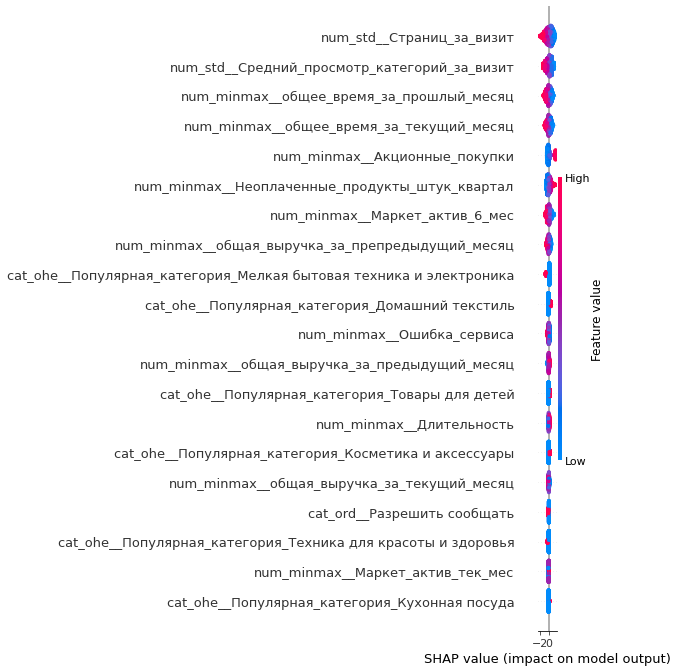

In [97]:
shap.summary_plot(shap_values, X_train_transformed, feature_names=feature_names)


Самые важные признаки:  

num_std__Страниц_за_визит и num_std__Средний_просмотр_категорий_за_визит — два наиболее влиятельных признака. Они оказывают сильное влияние на решение модели: больше страниц и категорий за визит → чаще НЕ снижается активность.  

Важна история взаимодействия:  

общее_время_за_прошлый_месяц, общее_время_за_текущий_месяц, общая_выручка_за_предыдущий/препредыдущий месяц — чем выше значения, тем меньше вероятность снижения. То есть прошлая активность и выручка — защита от снижения.  

Некоторые категориальные признаки тоже значимы:  

Популярные категории вроде "Мелкая бытовая техника" и "Домашний текстиль" влияют на результат, но не так сильно, как количественные признаки.  

Цветовая интерпретация:  

Вверху красные точки чаще справа от 0 — высокие значения увеличивают вероятность остаться активным.  

Внизу перемешано, влияние слабое или нестабильное.  



## Сегментация пользователей

In [98]:
model = best_models['logreg'][0]
y_pred_label = model.predict(X_test)

segment_df = X_test.copy()
segment_df['pred_label'] = y_pred_label
segment_df['true_label'] = y_test.values


segment_df['client_id'] = segment_df.index  


money = money.set_index('id')  


segment_df = segment_df.join(money['Прибыль'])

segment_df.rename(columns={'Прибыль': 'revenue'}, inplace=True)

median_revenue = segment_df['revenue'].median()

def assign_segment(row):
    if row['pred_label'] == 'Снизилась' and row['revenue'] > median_revenue:
        return 'B'  
    elif row['pred_label'] == 'Не снизилась' and row['revenue'] > median_revenue:
        return 'A' 
    elif row['pred_label'] == 'Снизилась':
        return 'D'  
    else:
        return 'C'  

segment_df['segment'] = segment_df.apply(assign_segment, axis=1)

NameError: name 'best_models' is not defined

In [ ]:
segment_counts = segment_df['segment'].value_counts()
print("Количество клиентов по сегментам:")
print(segment_counts)

print("\nПример результата:")
print(segment_df[['client_id', 'pred_label', 'true_label', 'revenue', 'segment']].head())

mean_revenue_by_segment = segment_df.groupby('segment')['revenue'].mean()
print("\nСредняя прибыль по сегментам:")
print(mean_revenue_by_segment)

### Исследуем группы покупателей

Сегмент B

In [ ]:
segment_b = segment_df[segment_df['segment'] == 'B']

plt.figure(figsize=(10, 5))
sns.histplot(segment_b['revenue'], bins=20, kde=True)
plt.title('Распределение прибыли клиентов сегмента B')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()



Большая часть клиентов сегмента B находится с прибылью чуть больше 4,5.

Сегмент C

In [ ]:
segment_c = segment_df[segment_df['segment'] == 'C']

plt.figure(figsize=(10, 5))
sns.histplot(segment_c['revenue'], bins=20, kde=True)
plt.title('Распределение прибыли клиентов сегмента C')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()

Большая часть данного сегмента приносит прибыл от 3 до 5, оптимально сосредоточиться именно на ней

In [ ]:
segment_d = segment_df[segment_df['segment'] == 'D']

plt.figure(figsize=(10, 5))
sns.histplot(segment_d['revenue'], bins=20, kde=True)
plt.title('Распределение прибыли клиентов сегмента D')
plt.xlabel('Прибыль')
plt.ylabel('Количество клиентов')
plt.show()

Понятно, что покупатели из сегмента D покупают мало, сосредоточиться надо на клиентах с прибылью от трёх до четырех.

### Выводы о сегментах

Сегмент B наиболее прибыльный, на нём нужно сосредоточиться в первую очередь, подобрать им персонализированные предложения. Далее сегмент C и сегмент D.

## Общий вывод

Задача проекта
Интернет-магазин «В один клик» столкнулся с проблемой снижения активности постоянных клиентов, при этом привлечение новых покупателей стало менее эффективным. Руководство компании поставило задачу — разработать решение для персонализации предложений постоянным клиентам с целью увеличения их покупательской активности. Анализ должен быть основан на данных и бизнес-моделировании.

1. Исходные данные и предобработка
В распоряжении были данные о поведении клиентов на сайте, их покупках и финансовых показателях.

    Проведён тщательный анализ данных на пропуски, дубликаты и выбросы.

    Был выявлен и удалён аномально большой выброс по выручке, а также исключены клиенты с нулевой активностью за последние 3 месяца.

    Распределение признаков нормализовано, мультиколлениарности не обнаружено.

    Исходные данные содержали поведенческие числовые признаки (просмотры, время на сайте, корзина) и финансовые показатели.

    Целевой признак — снижение покупательской активности.

2. Поиск и выбор модели
    Создан pipeline обработки данных и обучения моделей.

    Использована стратифицированная кросс-валидация для сбалансированной оценки, учитывая дисбаланс классов.

    Для оценки качества применялась метрика F1-score, сбалансированная между ошибками первого и второго рода.

    Обучены и протестированы четыре модели: KNN, дерево решений, логистическая регрессия и SVC.

    Лучшая модель — логистическая регрессия с гиперпараметром C=1, показавшая наилучший F1-score.


3. Важнейшие признаки, влияющие на снижение активности:

    Количество просмотренных страниц за визит (много просмотров при отсутствии покупок — тревожный сигнал).

    Среднее количество просмотренных категорий (чем больше, тем выше риск ухода).

    Общее время, проведённое на сайте (высокое время без покупки — возможный отказ).

    Количество неоплаченных товаров в корзине (потенциальные клиенты с риском ухода).

4. Мало значимые признаки:

Ошибки сервиса и длительность сессий.

Конкретные категории товаров и общая сумма покупок менее информативны для модели.

5. Сегментация клиентов:

    Выделены сегменты A, B, C, D по поведению и прибыли.

    Сегмент B — наиболее прибыльные, но с пониженной активностью клиенты.

    Сегмент C — стабильные, но менее прибыльные клиенты.

    Сегмент D — клиенты с пониженной активностью и низкой прибылью.

6. Рекомендации для работы с сегментом B:

    Фокус на удержании наиболее ценных клиентов, которые показывают снижение активности.

    Персонализированные маркетинговые акции и предложения.

    Улучшение клиентского сервиса и коммуникаций (например, напоминания, бонусы).

    Сбор обратной связи для выявления причин снижения интереса.
